In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set Plot Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size']= 12

## 1. Load Clean Data

In [6]:
# import dataframe
df = pd.read_csv('C:/Users/chapa/Desktop/retail-sales-analytics/data/clean/sales_clean.csv', parse_dates=['Order Date', 'Ship Date',])

In [7]:
# Look at df shape
df.shape

(9994, 27)

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Days to Ship,Profit Margin Percentage
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,4,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,4,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,4,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,4,7,11.25


## 2. KPI's

In [9]:
# Create Kpi's
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
avg_order_value = df['Sales'].mean()
overall_margin = (total_profit / total_revenue * 100)


print("=" * 40)
print("        KEY BUSINESS METRICS")
print("=" * 40)
print(f"  Total Revenue    : ${total_revenue:,.2f}")
print(f"  Total Profit     : ${total_profit:,.2f}")
print(f"  Profit Margin    : {overall_margin:.1f}%")
print(f"  Total Orders     : {total_orders:,}")
print(f"  Total Customers  : {total_customers:,}")
print(f"  Avg Order Value  : ${avg_order_value:,.2f}")
print("=" * 40)

        KEY BUSINESS METRICS
  Total Revenue    : $2,297,200.86
  Total Profit     : $286,397.02
  Profit Margin    : 12.5%
  Total Orders     : 5,009
  Total Customers  : 793
  Avg Order Value  : $229.86


## 3. Sales Trend Over TIme

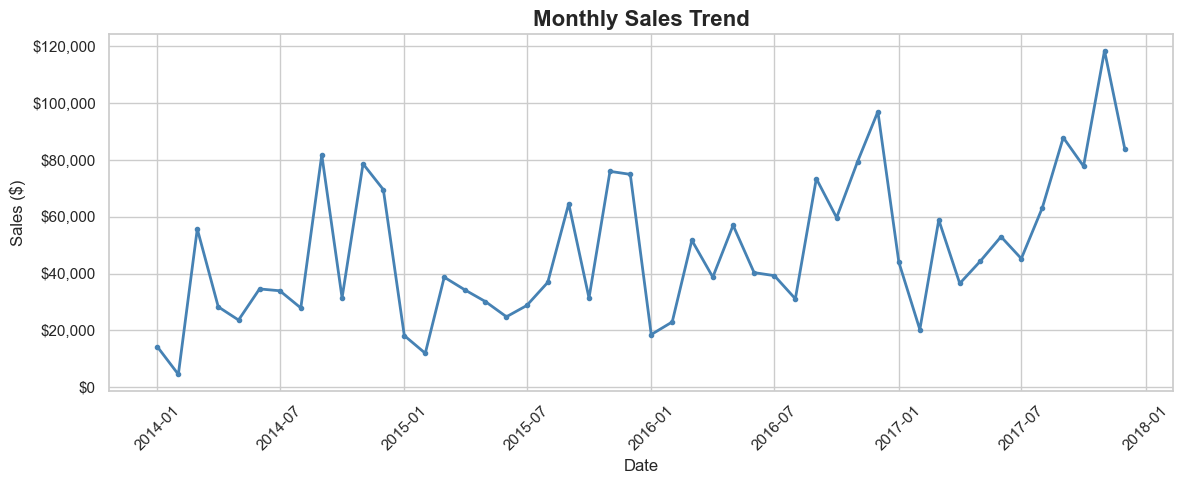

In [14]:
# monthly sales trends
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(
    {
        'year': monthly_sales['Order Year'],
        'month' : monthly_sales['Order Month'],
        'day' : 1
    }
)
# create plots
fig, ax = plt.subplots()
ax.plot(monthly_sales['Date'], monthly_sales['Sales'],
       color='steelblue', linewidth=2, marker='o', markersize=3)

ax.set_title("Monthly Sales Trend", fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/chapa/Desktop/retail-sales-analytics/visuals/01_monthly_sales_trend.png', dpi=150)
plt.show()
                                                   

## 4. Sales by Category

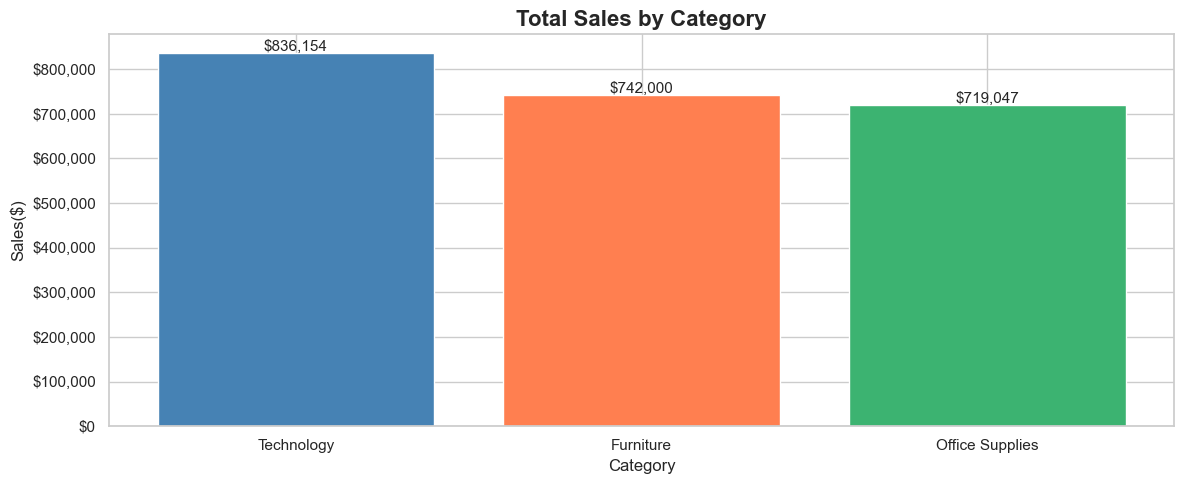

In [16]:
# sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

#create plot
fig, ax = plt.subplots()
bars = ax.bar(category_sales['Category'], category_sales['Sales'],
             color=['steelblue', 'coral', 'mediumseagreen'])

ax.set_title('Total Sales by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Sales($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#add value label on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
           f'${bar.get_height():,.0f}', ha='center', fontsize=11)
    
plt.tight_layout()
plt.savefig('C:/Users/chapa/Desktop/retail-sales-analytics/visuals/02_sales_by_category.png', dpi=150)
plt.show()

## 5. Sales by Region

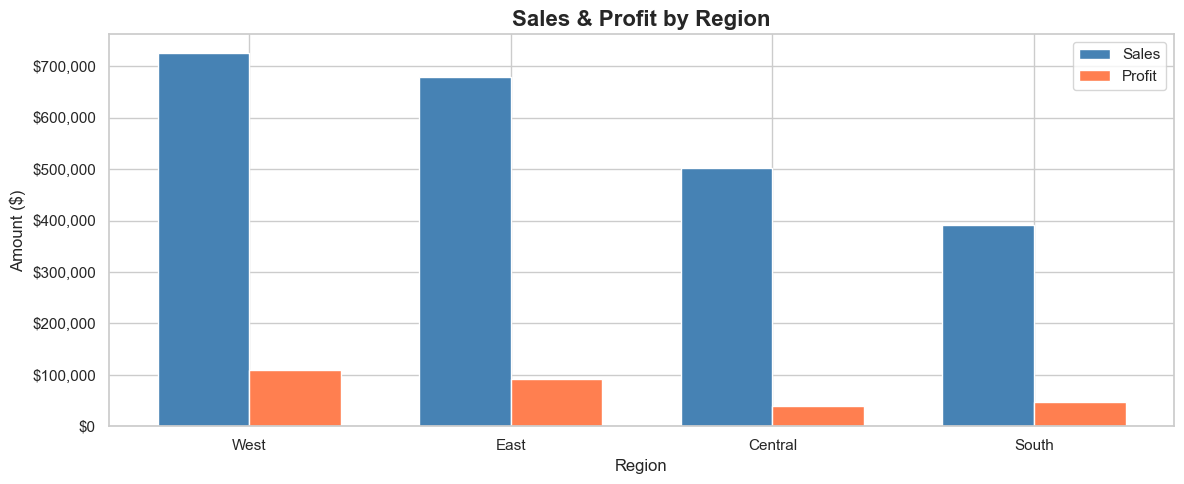

In [17]:
# sales and profit by region
region_data = df.groupby('Region')[['Sales','Profit']].sum().reset_index()
region_data = region_data.sort_values('Sales', ascending=False)

x = np.arange(len(region_data))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, region_data['Sales'], width, label='Sales', color='steelblue')
bars2 = ax.bar(x + width/2, region_data['Profit'], width, label='Profit', color='coral')

ax.set_title('Sales & Profit by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(region_data['Region'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _:f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/chapa/Desktop/retail-sales-analytics/visuals/03_sales_profit_by_region.png', dpi=150)
plt.show()

## 6. Top 10 Products by Sales

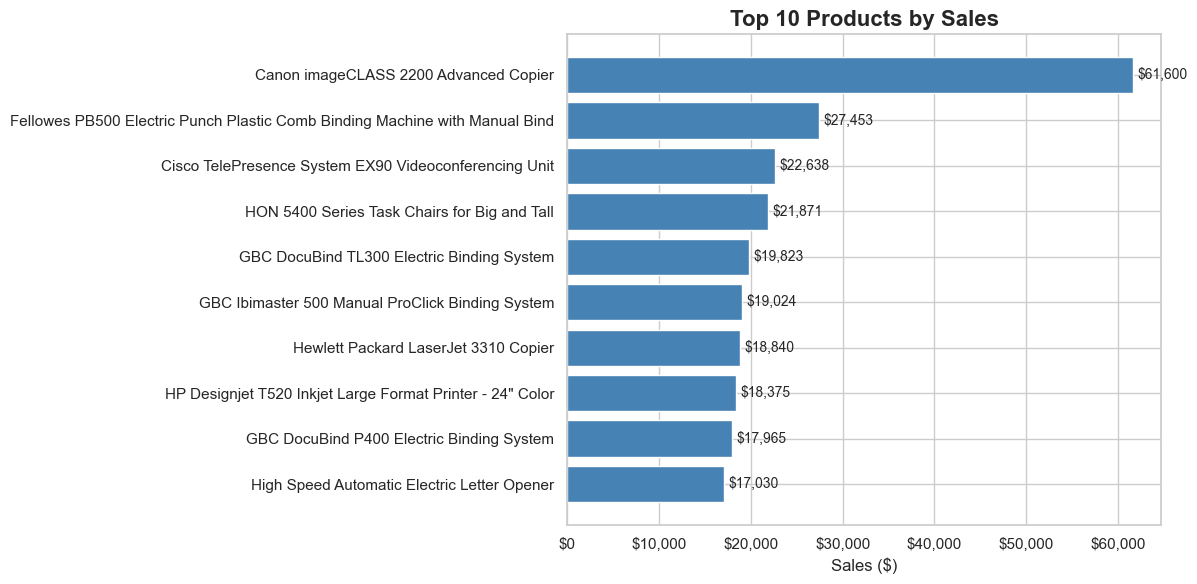

In [21]:
#group top 10 products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# create graph
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.barh(top_products['Product Name'], top_products['Sales'], color='steelblue')

ax.set_title('Top 10 Products by Sales', fontsize=16, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()

# add value labels
for bar in bars:
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
           f'${bar.get_width():,.0f}', va='center', fontsize=10)
    
plt.tight_layout()
plt.savefig('C:/Users/chapa/Desktop/retail-sales-analytics/visuals/04_top_10_products.png', dpi=150)
plt.show()

## 7. Discount vs Profit 

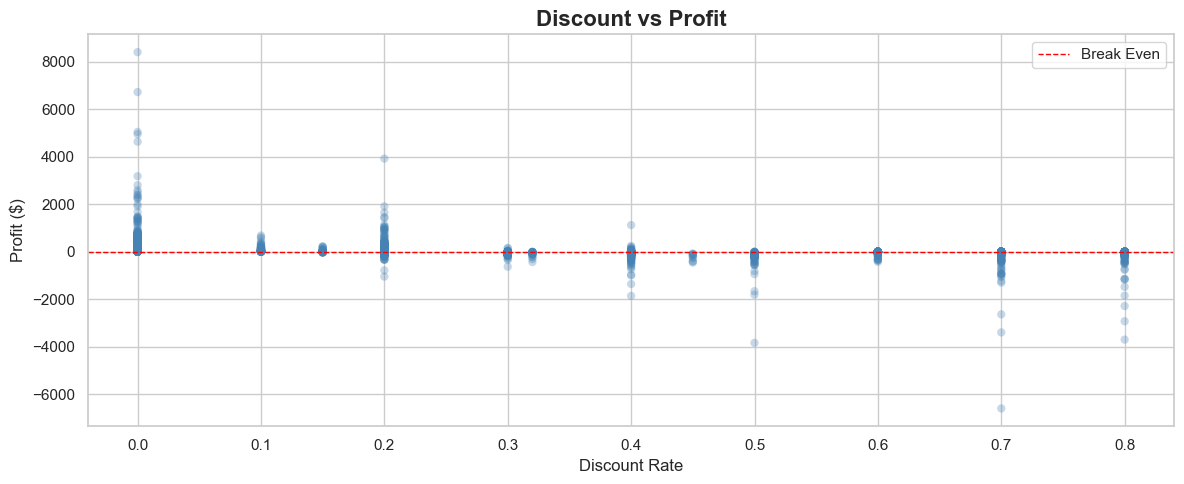

In [23]:
# find the impact of discounts on profit
fig, ax = plt.subplots()
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', edgecolors='none')

ax.set_title("Discount vs Profit", fontsize=16, fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break Even')
ax.legend()
plt.tight_layout()
plt.savefig('C:/Users/chapa/Desktop/retail-sales-analytics/visuals/05_discount_vs_profit.png', dpi=150)
plt.show()